# Face Detection

## HOG+SVM+NMS

### HOG
HOG (Histogram of Oriented Gradients) is a feature descriptor method used in computer vision and image processing, primarily for object detection (e.g., faces, pedestrians, vehicles)

The HOG feature extraction process can be broken down into the following steps:

- Image Preprocessing
    - Typically, the image is converted to grayscale (to reduce computational cost).

    - Gamma correction can be applied to adjust for lighting variations.

- Gradient Computation
    - Use the Sobel operator or simple differencing to compute the gradient for each pixel:Horizontal gradient $G_X$ and Vertical gradient $G_y$

- Compute the magnitude and orientation of the gradient:
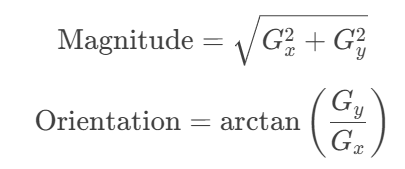

- Dividing into Cells and Computing Histograms
    - Divide the image into small Cells (e.g., 8×8 pixels).

    - For each Cell, compute a histogram of gradient orientations (typically binned into 9 directions).

- Block Normalization
    - Group multiple Cells into a Block (e.g., 2×2 Cells = 16×16 pixels).

    - Normalize the histograms within each Block (e.g., using L2-Norm) to improve robustness to lighting and contrast variations.

- Concatenating All Block Features
    - Combine all Block feature vectors to form the final HOG feature vector.

### NMS
Non-Maximum Suppression is a post-processing technique commonly used in computer vision, particularly in object detection tasks. Its purpose is to select the best bounding box among overlapping detections while suppressing all others. It is a crucial step in many modern object detection algorithms such as YOLO, Faster R-CNN, etc.


NMS's steps as follow:
- Input- A set of bounding boxes with their corresponding confidence scores

- Sort all bounding boxes by their confidence scores in descending order

- Start with the box that has the highest score

- Remove all other boxes that have a high overlap (measured by Intersection over Union - IoU) with this box

- Repeat the process with the next highest-scoring box from the remaining boxes

**Key Parameters**
- IoU Threshold: The overlap threshold (typically between 0.3-0.5) above which boxes are considered duplicates

- Confidence Threshold: Minimum score required for a box to be considered

**Model limitation**:

The HOG+SVM+NMS method has relatively low performance in the era of deep learning

*This example demonstrates the complete process of implementing face detection with traditional computer vision methods. Although it is not as powerful as deep learning methods, it is very helpful for understanding the basic principles.*

In [15]:
import os
import time
import torch
from torchvision.ops import nms
import torchvision.transforms as transforms
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from skimage.feature import hog
import tempfile
import urllib.request
import zipfile

In [2]:
# 1.Data Preparation - from Pytorch LFW

def prepare_dataset():
    # 使用Windows兼容的路径写法
    base_dir = os.path.join('data', 'face_detection')
    pos_dir = os.path.join(base_dir, 'positive_samples')
    neg_dir = os.path.join(base_dir, 'negative_samples')
    
    os.makedirs(pos_dir, exist_ok=True)
    os.makedirs(neg_dir, exist_ok=True)
    
    # 下载示例正样本（使用预先准备好的小型人脸数据集）
    print("Downloading sample positive images...")
    sample_faces_url = "https://github.com/opencv/opencv/raw/master/samples/data/lena.jpg"
    
    try:
        # 下载几个示例人脸
        for i in range(5):
            urllib.request.urlretrieve(sample_faces_url, os.path.join(pos_dir, f'face_{i}.jpg'))
    except:
        # 如果下载失败，创建一些简单的人脸替代图像
        for i in range(5):
            img = Image.new('RGB', (64, 64), color='red')
            img.save(os.path.join(pos_dir, f'face_{i}.jpg'))

    print("Creating negative samples...")
    for i in range(10):
        img = Image.new('RGB', (64, 64), color=(np.random.randint(0, 255), 
                                               np.random.randint(0, 255), 
                                               np.random.randint(0, 255)))
        img.save(os.path.join(neg_dir, f'bg_{i}.jpg'))
    
    print(f"Dataset prepared at {base_dir}")
    
def load_face_dataset():
    base_dir = os.path.join('data', 'face_detection')
    pos_dir = os.path.join(base_dir, 'positive_samples')
    neg_dir = os.path.join(base_dir, 'negative_samples')
    
    # 检查数据集是否存在
    if not (os.path.exists(pos_dir) and os.path.exists(neg_dir)):
        prepare_dataset()

    pos_images = []
    for img_file in sorted(os.listdir(pos_dir)):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img = Image.open(os.path.join(pos_dir, img_file))
                pos_images.append(img)
            except Exception as e:
                print(f"Error loading {img_file}: {e}")
                
    neg_images = []
    for img_file in sorted(os.listdir(neg_dir)):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img = Image.open(os.path.join(neg_dir, img_file))
                neg_images.append(img)
            except Exception as e:
                print(f"Error loading {img_file}: {e}")
    
    print(f"Loaded {len(pos_images)} positive and {len(neg_images)} negative samples")
    return pos_images, neg_images    
    

In [3]:
# 2. HOG feature detection(use skimage)
def extract_hog_features(images, target_size=(64, 64)):
    """
    :param images: PIL img list
    :param target_size: resize img to same size
    :return: HOG feature matrix
    """
    features = []
    for img in images:
        # resize & RGB2GRAY
        img = img.resize(target_size).convert('L')
        img_array = np.array(img)
        
        # calc HOG feature
        fd = hog(img_array, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        
        features.append(fd)
    
    return np.array(features)


In [4]:
# 3. train SVM
def train_svm(pos_features, neg_features):
    """
    :param pos_features: pos-sample
    :param neg_features: neg-sample
    :return: trained SVM model
    """
    # lable (1-hunman face,0-others)
    pos_labels = np.ones(len(pos_features))
    neg_labels = np.zeros(len(neg_features))
    
    # combine feature and labels
    X = np.vstack((pos_features, neg_features))
    y = np.hstack((pos_labels, neg_labels))
    
    # create and train SVM
    svm = make_pipeline(
        StandardScaler(),
        LinearSVC(C=0.1, loss='hinge', max_iter=10000, random_state=42)
    )
    
    print(pos_features)
    print(neg_features)
    print(y)
    svm.fit(X, y)
    
    return svm


In [5]:
# 4. sliding window detection
def sliding_window(image, window_size=(64, 64), stride=16):
    """
    :param image: input img(PIL Image)
    :param window_size: size of window
    :param stride: sliding stride
    :yield: (x, y, window_image)
    """
    img_width, img_height = image.size
    window_width, window_height = window_size
    
    for y in range(0, img_height - window_height, stride):
        for x in range(0, img_width - window_width, stride):
            # crop window
            window = image.crop((x, y, x + window_width, y + window_height))
            yield (x, y, window)


In [6]:
# 5. multi-scale detection
def multi_scale_detection(image, svm, scales=[0.5, 1.0, 1.5, 2.0]):
    """
    :param image: input img(PIL Image)
    :param svm: trained SVM model
    :param scales: scale table
    :return: result list (x, y, width, height, score)
    """

    detections = []
    original_width, original_height = image.size
    
    for scale in scales:
        # scale img
        scaled_width = int(original_width * scale)
        scaled_height = int(original_height * scale)
        scaled_img = image.resize((scaled_width, scaled_height))
        
        # sliding window detection
        for (x, y, window) in sliding_window(scaled_img):
            # extract HOG feature
            hog_feature = extract_hog_features([window])
            
            # predict
            score = svm.decision_function(hog_feature)
            
            # when score > threshold(here 0)，record result
            if score > 0:
                # change coordinate/size to ori scale
                orig_x = int(x / scale)
                orig_y = int(y / scale)
                orig_width = int(64 / scale)
                orig_height = int(64 / scale)
                
                detections.append([orig_x, orig_y, orig_width, orig_height, score[0]])
    
    return np.array(detections)

In [7]:
# 6. Non-maximum Suppression (NMS)
def apply_nms(detections, iou_threshold=0.3):
    """
    :param detections: detection result list (x, y, width, height, score)
    :param iou_threshold: IoU threshold
    :return: index of detection result
    """
    if len(detections) == 0:
        return []
    
    # change toPyTorch tensor
    boxes = torch.tensor(detections[:, :4], dtype=torch.float32)
    scores = torch.tensor(detections[:, 4], dtype=torch.float32)
    
    # change data format, (x,y,width,height)-->(x1,y1,x2,y2)
    boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
    boxes[:, 3] = boxes[:, 1] + boxes[:, 3]
    
    # NMS
    keep_indices = nms(boxes, scores, iou_threshold)
    
    return keep_indices.numpy()

Loading dataset...
Loaded 603 positive and 274 negative samples
Loaded 603 positive samples and 274 negative samples
Loading dataset...
Loaded 603 positive and 274 negative samples
Extracting HOG features from positive samples...
Extracting HOG features from negative samples...
Training SVM...
[[0.38182745 0.38182745 0.38182745 ... 0.16405403 0.1735937  0.20520353]
 [0.02753584 0.         0.00584011 ... 0.01777251 0.06235149 0.36004391]
 [0.04772105 0.04308945 0.02981668 ... 0.32343211 0.03988842 0.01260181]
 ...
 [0.008931   0.01304288 0.02106935 ... 0.00273899 0.00649609 0.        ]
 [0.07773553 0.06518322 0.06916271 ... 0.         0.00501646 0.01259889]
 [0.04815685 0.         0.00140774 ... 0.00426472 0.         0.00224935]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.10681574 0.02225401 0.00888011 ... 0.033166   0.25274258 0.22091682]
 [0.08976396 0.01808897 0.05112116 ... 0.03490725 0.         0.06910946]
 ...
 [0.29280545 0.29280545 0.03081472 ..

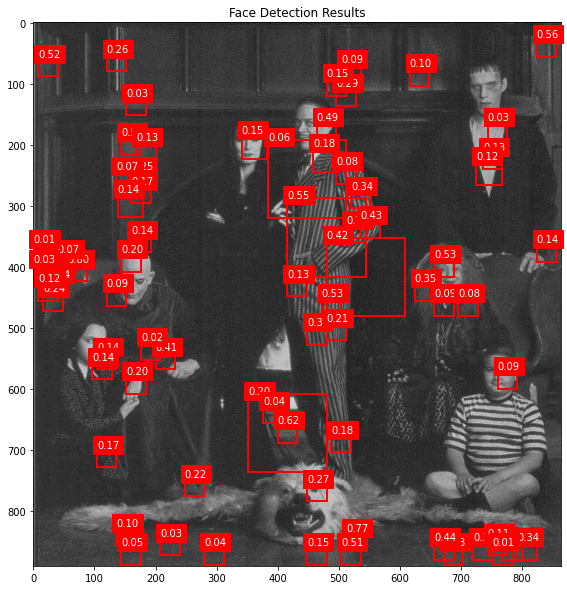

In [16]:
def main():
    # 1.Data Preparation
    print("Loading dataset...")
    pos_images, neg_images = load_face_dataset()
    
    print(f"Loaded {len(pos_images)} positive samples and {len(neg_images)} negative samples")
    print("Loading dataset...")
    pos_images, neg_images = load_face_dataset()
    
    # limit the size of samples to quick the calculation
    pos_images = pos_images[:1000]
    neg_images = neg_images[:1000]
    
    #2. HOG feature detection
    print("Extracting HOG features from positive samples...")
    pos_features = extract_hog_features(pos_images)
    print("Extracting HOG features from negative samples...")
    neg_features = extract_hog_features(neg_images)
    
    # 3. train SVM
    print("Training SVM...")
    svm = train_svm(pos_features, neg_features)
    print("Training completed.")

   
    #change the dir to your own
    test_image = Image.open(r"C:\Users\wwy\Documents\计算机视觉\2025spring\lab\lab13\data\face_detection\test_image\addams-family.jpg").convert('RGB')
    
    # 5. multi-scale detection<--4. sliding window detection
    print("Detecting faces...")
    start_time = time.time()
    detections = multi_scale_detection(test_image, svm)
    print(f"Detection completed in {time.time() - start_time:.2f} seconds.")
    
    # 6. Non-maximum Suppression (NMS)
    keep_indices = apply_nms(detections)
    final_detections = detections[keep_indices]
    
    # 7. visualization
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(test_image)
    
    for detection in final_detections:
        x, y, width, height, score = detection
        rect = patches.Rectangle(
            (x, y), width, height, 
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x, y, f"{score:.2f}", color='white', backgroundcolor='red')
    
    plt.title("Face Detection Results")
    plt.show()

if __name__ == "__main__":
    main()